In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import seaborn as sns


In [87]:
# Step 1: Load the datasets
df_class_0 = pd.read_csv("dataset/features_subset_0_lbp.csv")
df_class_1 = pd.read_csv("dataset/features_subset_1_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0['target'] = 0  # Label for class 0
df_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined = pd.concat([df_class_0, df_class_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined = df_combined.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [88]:
df_combined.head()

,Unnamed: 0,GLCM_1_Contrast,GLCM_1_Correlation,GLCM_1_Energy,GLCM_1_Homogeneity,morphological_1_area,morphological_1_perimeter,morphological_1_eccentricity,morphological_1_major_axis_length,morphological_1_minor_axis_length,...,morphological_35_perimeter,morphological_35_eccentricity,morphological_35_major_axis_length,morphological_35_minor_axis_length,morphological_37_perimeter,morphological_37_minor_axis_length,morphological_40_perimeter,morphological_40_eccentricity,morphological_40_major_axis_length,morphological_40_minor_axis_length
0,12893_idx5_x351_y1801_class1.png,0.000353,772.089406,0.052902,649.289580,1493.0,878.097546,0.323150,61.084026,57.806733,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,12893_idx5_x1351_y1001_class0.png,0.000833,703.571329,0.101885,780.174587,2482.0,257.982756,0.073353,57.878728,57.722805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12893_idx5_x1251_y1351_class1.png,0.000319,1108.067010,0.050051,1047.306859,1938.0,824.630555,0.228198,58.587054,57.041219,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,12893_idx5_x451_y501_class0.png,0.021546,492.007087,0.320853,1023.352011,2446.0,270.361436,0.168651,58.064816,57.233085,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12893_idx5_x1201_y1251_class0.png,0.000508,596.879163,0.067381,540.617616,2424.0,327.722871,0.229652,58.090354,56.537767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Columns: 216 entries, Unnamed: 0 to morphological_40_minor_axis_length
dtypes: float64(214), int64(1), object(1)
memory usage: 314.0+ KB


In [90]:
df_combined.fillna(0, inplace=True)

In [91]:
# Step 4: Separate features (X) and target (y)
X = df_combined.drop(columns=['target', 'Unnamed: 0'])  # Features
y = df_combined['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=142)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [92]:
# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.868421052631579

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86        18
           1       0.89      0.85      0.87        20

    accuracy                           0.87        38
   macro avg       0.87      0.87      0.87        38
weighted avg       0.87      0.87      0.87        38

ROC-AUC Score: 0.9


[[16  2]
 [ 3 17]]


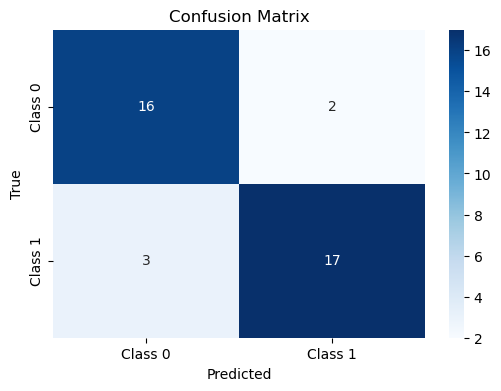

In [93]:
# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [94]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy: ", scores.mean())

Cross-Validation Accuracy:  0.8440967283072546


In [95]:
from sklearn.feature_selection import SelectKBest, chi2

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)

rf = RandomForestClassifier(random_state=142, bootstrap=False, max_depth=3, min_samples_leaf=1,
                           min_samples_split=2, n_estimators=500, class_weight={1:2.5,0:1.2})
# Apply SelectKBest
selector = SelectKBest(score_func=chi2, k=20)  # k="all" to get scores for all features
#selector.fit(X_train, y_train)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)


rf.fit(X_train_selected, y_train)
# Get the scores of the selected features
feature_scores = selector.scores_

# Get the names of the features
feature_names = X_train.columns

# Create a DataFrame with feature names and their corresponding scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': feature_scores
})

# Sort the features by score
feature_importance_df = feature_importance_df.sort_values(by='Score', ascending=False)

# Display the selected features with their scores
print(feature_importance_df)

# Predict on the test set
y_pred = rf.predict(X_test_selected)
y_pred_prob = rf.predict_proba(X_test_selected)[:, 1]  # Probabilities for the positive class

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

scores = cross_val_score(rf, X, y, cv=10, scoring='accuracy')
print(f"Cross-Validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

                       Feature         Score
4         morphological_1_area  16202.479555
14        morphological_3_area   5448.065330
1           GLCM_1_Correlation   4270.455884
5    morphological_1_perimeter   3068.034051
15   morphological_3_perimeter   3014.523116
..                         ...           ...
150                      LBP_5      0.002157
152                      LBP_7      0.001807
154                      LBP_9      0.000318
149                      LBP_4      0.000110
146                      LBP_1      0.000078

[214 rows x 2 columns]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79        18
           1       0.78      0.90      0.84        20

    accuracy                           0.82        38
   macro avg       0.82      0.81      0.81        38
weighted avg       0.82      0.82      0.81        38

Confusion Matrix:
[[13  5]
 [ 2 18]]
Cross-Validation Accuracy: 0.8336 ± 0.0735


In [96]:
# Extract the sample IDs
sample_ids = df_combined["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined[df_combined['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_se'] = np.std(nonzero_values) / np.sqrt(len(nonzero_values))
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_se'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

                           Sample_ID  count_objects    area_mean  area_max  \
0   12893_idx5_x351_y1801_class1.png             23    66.652174    1493.0   
1  12893_idx5_x1351_y1001_class0.png              1  2482.000000    2482.0   
2  12893_idx5_x1251_y1351_class1.png              5   388.800000    1938.0   
3    12893_idx5_x451_y501_class0.png              2  1224.000000    2446.0   
4  12893_idx5_x1201_y1251_class0.png              4   606.750000    2424.0   

   area_min     area_se  perimeter_mean  perimeter_max  perimeter_min  \
0       1.0   63.409540      179.226616     878.097546       3.207107   
1    2482.0    0.000000      257.982756     257.982756     257.982756   
2       1.0  346.411824      412.918831     824.630555       1.207107   
3       2.0  864.084487      270.361436     270.361436     270.361436   
4       1.0  524.594888      327.722871     327.722871     327.722871   

   perimeter_se  ...  eccentricity_min  eccentricity_se  \
0    156.273093  ...          0.3

In [97]:

# Drop morphological features from original_df
morphological_features = [col for col in df_combined.columns if col.startswith("morphological_")]
filtered_df = df_combined.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df = filtered_df.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
merged_df.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df.shape)

Merged DataFrame shape: (186, 38)


In [98]:
merged_df

,Unnamed: 0,GLCM_1_Contrast,GLCM_1_Correlation,GLCM_1_Energy,GLCM_1_Homogeneity,LBP_0,LBP_1,LBP_2,LBP_3,LBP_4,...,eccentricity_min,eccentricity_se,major_axis_length_mean,major_axis_length_max,major_axis_length_min,major_axis_length_se,minor_axis_length_mean,minor_axis_length_max,minor_axis_length_min,minor_axis_length_se
0,12893_idx5_x351_y1801_class1.png,0.000353,772.089406,0.052902,649.289580,0.1228,0.1124,0.0704,0.0644,0.0760,...,0.323150,0.067887,9.179339,61.084026,2.000000,6.120716,12.845751,57.806733,1.333333,10.054024
1,12893_idx5_x1351_y1001_class0.png,0.000833,703.571329,0.101885,780.174587,0.1396,0.1188,0.0524,0.0760,0.0812,...,0.073353,0.000000,57.878728,57.878728,57.878728,0.000000,57.722805,57.722805,57.722805,0.000000
2,12893_idx5_x1251_y1351_class1.png,0.000319,1108.067010,0.050051,1047.306859,0.1152,0.1088,0.0768,0.0764,0.0780,...,0.228198,0.263583,31.132071,58.587054,3.677089,19.413605,28.939311,57.041219,0.837402,19.871050
3,12893_idx5_x451_y501_class0.png,0.021546,492.007087,0.320853,1023.352011,0.1052,0.0992,0.0384,0.0824,0.0780,...,0.168651,0.293926,30.032408,58.064816,2.000000,19.821906,57.233085,57.233085,57.233085,0.000000
4,12893_idx5_x1201_y1251_class0.png,0.000508,596.879163,0.067381,540.617616,0.1452,0.1216,0.0508,0.0608,0.0616,...,0.229652,0.000000,58.090354,58.090354,58.090354,0.000000,56.537767,56.537767,56.537767,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,12893_idx5_x1001_y2201_class1.png,0.000335,1171.038665,0.063665,1647.381937,0.1248,0.1156,0.0636,0.0692,0.0732,...,0.688275,0.019000,7.363025,61.790128,2.000000,3.328199,6.264825,44.825635,0.828427,4.549136
182,12893_idx5_x751_y1201_class0.png,0.000861,489.499771,0.100642,488.254519,0.1520,0.1172,0.0588,0.0588,0.0620,...,0.247906,0.257791,31.832443,57.653400,6.011487,18.258173,28.567121,55.853692,1.280549,19.294520
183,12893_idx5_x1051_y1051_class0.png,0.000605,626.955012,0.083756,809.770043,0.1328,0.1140,0.0648,0.0772,0.0728,...,0.197282,0.000000,58.129489,58.129489,58.129489,0.000000,56.987060,56.987060,56.987060,0.000000
184,12893_idx5_x1401_y1601_class1.png,0.000290,1366.057551,0.047601,1583.580753,0.1160,0.1040,0.0680,0.0732,0.0912,...,0.258073,0.058633,7.914399,61.947830,2.000000,4.709064,11.574230,59.849367,1.333333,8.817183


In [99]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              186 non-null    object 
 1   GLCM_1_Contrast         186 non-null    float64
 2   GLCM_1_Correlation      186 non-null    float64
 3   GLCM_1_Energy           186 non-null    float64
 4   GLCM_1_Homogeneity      186 non-null    float64
 5   LBP_0                   186 non-null    float64
 6   LBP_1                   186 non-null    float64
 7   LBP_2                   186 non-null    float64
 8   LBP_3                   186 non-null    float64
 9   LBP_4                   186 non-null    float64
 10  LBP_5                   186 non-null    float64
 11  LBP_6                   186 non-null    float64
 12  LBP_7                   186 non-null    float64
 13  LBP_8                   186 non-null    float64
 14  LBP_9                   186 non-null    fl

In [112]:
# Step 4: Separate features (X) and target (y)
X = merged_df.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=142, max_depth=None)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [113]:
# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.8947368421052632

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        18
           1       0.90      0.90      0.90        20

    accuracy                           0.89        38
   macro avg       0.89      0.89      0.89        38
weighted avg       0.89      0.89      0.89        38

ROC-AUC Score: 0.9222222222222223


[[16  2]
 [ 2 18]]


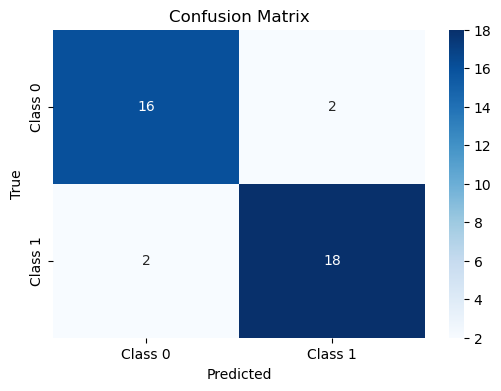

In [114]:
# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

                   Feature  Importance
16                area_max    0.101467
2            GLCM_1_Energy    0.093635
29   major_axis_length_min    0.059106
20           perimeter_max    0.056853
0          GLCM_1_Contrast    0.053128
24        eccentricity_max    0.047912
33   minor_axis_length_min    0.045546
15               area_mean    0.039937
1       GLCM_1_Correlation    0.037637
23       eccentricity_mean    0.037086
31  minor_axis_length_mean    0.036511
17                area_min    0.034297
21           perimeter_min    0.034012
27  major_axis_length_mean    0.024745
14           count_objects    0.021145
25        eccentricity_min    0.019795
18                 area_se    0.019243
19          perimeter_mean    0.018799
13                   LBP_9    0.018691
10                   LBP_6    0.017183
32   minor_axis_length_max    0.016907
28   major_axis_length_max    0.016715
4                    LBP_0    0.016222
3       GLCM_1_Homogeneity    0.015117
11                   LBP_

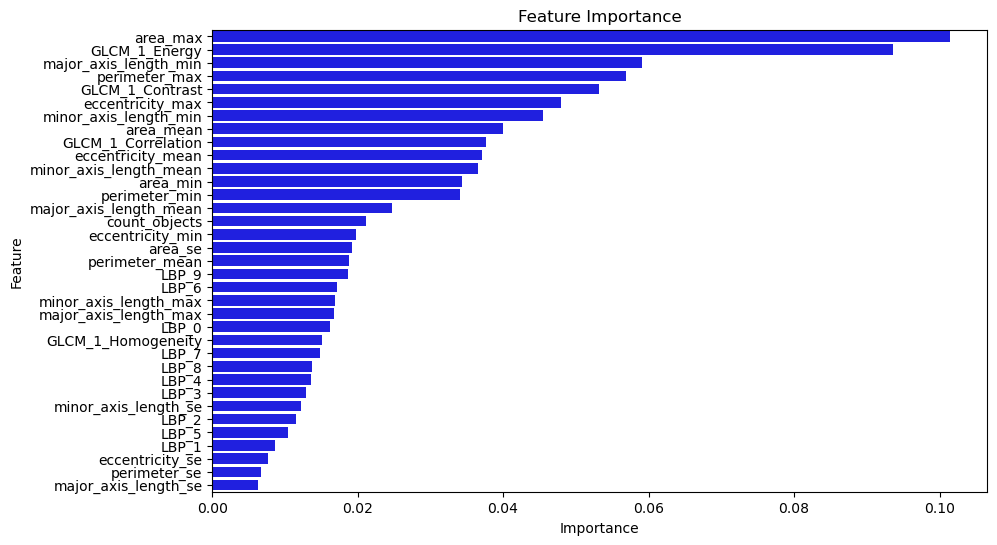

In [115]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Now, I will try the approach with normalization and standartization of features:

In [116]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [117]:
# Step 4: Separate features (X) and target (y)
X = merged_df.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)

# Option 1: Normalize features to [0, 1]
normalizer = MinMaxScaler()
X_train_normalized = normalizer.fit_transform(X_train)
X_test_normalized =normalizer.transform(X_test)


# Option 2: Standardize features to mean=0, std=1
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

# Convert back to DataFrame
#features_normalized_df = pd.DataFrame(features_normalized, columns=features.columns)
#features_standardized_df = pd.DataFrame(features_standardized, columns=features.columns)

# Add back image names
#features_normalized_df['Image Name'] = image_names
#features_standardized_df['Image Name'] = image_names

# Save normalized/standardized features
#features_normalized_df.to_csv("normalized_features.csv", index=False)
#features_standardized_df.to_csv("standardized_features.csv", index=False)

### As I could see, it did not improve rf. Lets try - to train n´model on a big dataset but with scaler/normalizer trained by small dataset.

In [121]:
# Step 1: Load the datasets
df_class_0 = pd.read_csv("dataset/features_set_0_lbp.csv")
df_class_1 = pd.read_csv("dataset/features_set_1_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0['target'] = 0  # Label for class 0
df_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined = pd.concat([df_class_0, df_class_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined = df_combined.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [122]:
# Extract the sample IDs
sample_ids = df_combined["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined[df_combined['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_se'] = np.std(nonzero_values) / np.sqrt(len(nonzero_values))
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_se'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

                           Sample_ID  count_objects  area_mean  area_max  \
0   13693_idx5_x2351_y851_class0.png              1    2497.00    2497.0   
1   12749_idx5_x2501_y851_class1.png             40       2.45      12.0   
2  10285_idx5_x1151_y1001_class1.png              6     309.50    1843.0   
3   12894_idx5_x601_y1851_class0.png              1    2475.00    2475.0   
4  14155_idx5_x2401_y1351_class1.png              1    2266.00    2266.0   

   area_min     area_se  perimeter_mean  perimeter_max  perimeter_min  \
0    2497.0    0.000000      209.313708     209.313708     209.313708   
1       1.0    0.415256        4.899916      11.207107       1.000000   
2       1.0  279.977851      244.125153     969.257972       1.414214   
3    2475.0    0.000000      292.166522     292.166522     292.166522   
4    2266.0    0.000000      648.227489     648.227489     648.227489   

   perimeter_se  ...  eccentricity_min  eccentricity_se  \
0      0.000000  ...          0.036880       

In [123]:

# Drop morphological features from original_df
morphological_features = [col for col in df_combined.columns if col.startswith("morphological_")]
filtered_df = df_combined.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df = filtered_df.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
merged_df.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df.shape)

Merged DataFrame shape: (1121, 38)


In [130]:
# Step 4: Separate features (X) and target (y)
X = merged_df.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)

X_train_normalized=scaler.transform(X_train)
X_test_normalized=scaler.transform(X_test)



In [126]:
# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=142, max_depth=None)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)


Accuracy: 0.7733333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75       100
           1       0.80      0.78      0.79       125

    accuracy                           0.77       225
   macro avg       0.77      0.77      0.77       225
weighted avg       0.77      0.77      0.77       225

ROC-AUC Score: 0.8584799999999999
[[76 24]
 [27 98]]


In [131]:
# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=142, max_depth=None)
rf_model.fit(X_train_normalized, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test_normalized)
y_pred_proba = rf_model.predict_proba(X_test_normalized)[:, 1]

# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)


Accuracy: 0.7688888888888888

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.76      0.75       100
           1       0.80      0.78      0.79       125

    accuracy                           0.77       225
   macro avg       0.77      0.77      0.77       225
weighted avg       0.77      0.77      0.77       225

ROC-AUC Score: 0.8590399999999999
[[76 24]
 [28 97]]
